In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [9]:
iris = load_iris()

In [10]:
print(iris.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [11]:
print(iris.data.shape)
print(iris.target.shape)

(150, 4)
(150,)


In [12]:
print(iris.feature_names)
print(iris.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [13]:
X = iris.data
y = iris.target

In [14]:
print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [15]:
print(X[:5])
print(y[:5])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0]


In [16]:
df = pd.DataFrame(X, columns=iris.feature_names)
df["species"]=y
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [18]:
df["species"].value_counts()

species
0    50
1    50
2    50
Name: count, dtype: int64

In [19]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [20]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

In [21]:
df["species"].value_counts()

species
0    50
1    50
2    50
Name: count, dtype: int64

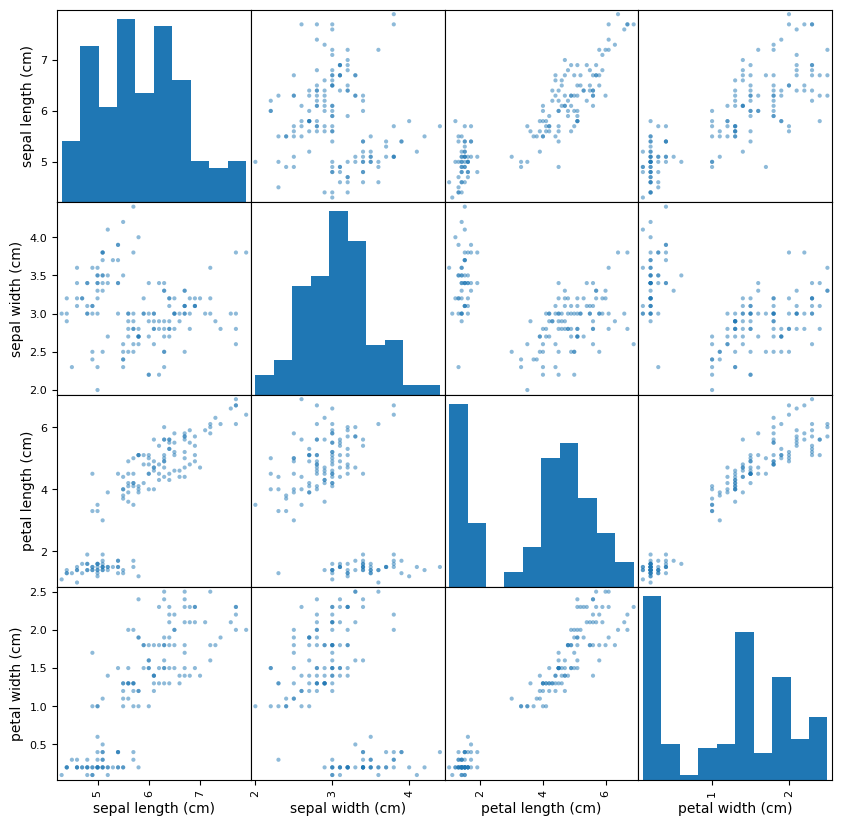

In [22]:
pd.plotting.scatter_matrix(
    df.iloc[:, :4],
    figsize=(10, 10)
)
plt.show()

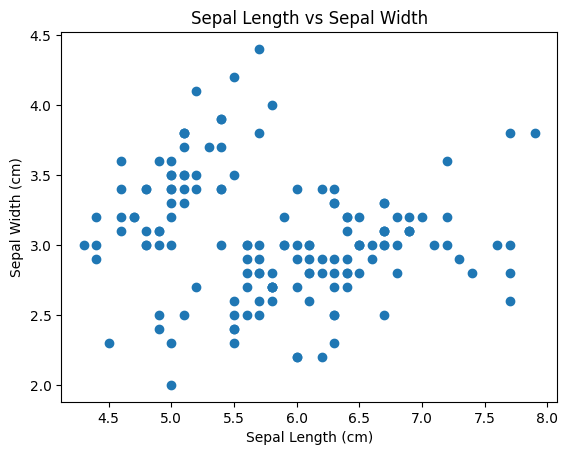

In [23]:
plt.scatter(df["sepal length (cm)"], df["sepal width (cm)"])
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.title("Sepal Length vs Sepal Width")
plt.show()

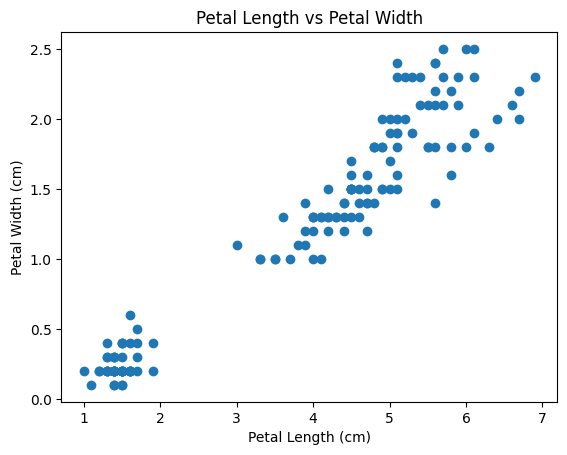

In [24]:
plt.scatter(
    df["petal length (cm)"],
    df["petal width (cm)"]
)
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Petal Length vs Petal Width")
plt.show()

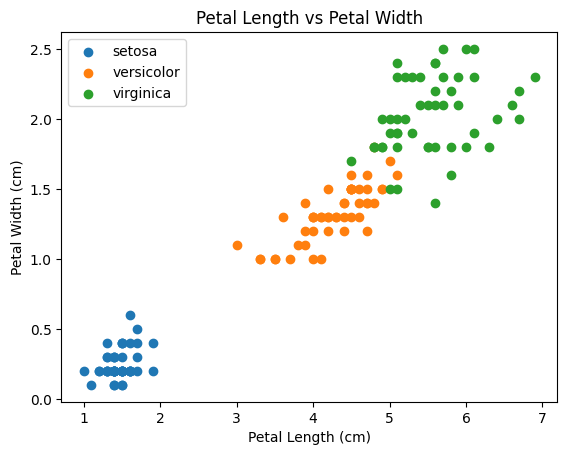

In [25]:
for species in range(3):
    subset = df[df["species"]==species]
    plt.scatter(
        subset["petal length (cm)"],
        subset["petal width (cm)"],
        label = iris.target_names[species]
    )

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Petal Length vs Petal Width")
plt.legend()
plt.show()

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(120, 4)
(30, 4)
(120,)
(30,)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
print(pd.Series(y_train).value_counts())
print(pd.Series(y_test).value_counts())

0    40
2    40
1    40
Name: count, dtype: int64
0    10
2    10
1    10
Name: count, dtype: int64


In [30]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(y_pred)
print("----------------------------")
print(y_test)

[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]
----------------------------
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [31]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

Accuracy:  1.0


In [32]:
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 100.00%


In [33]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


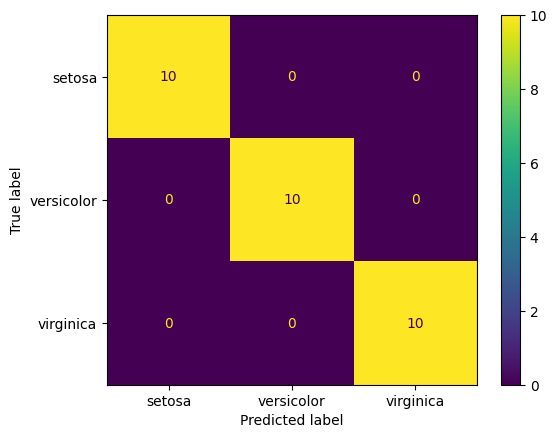

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
).plot()

plt.show()

In [35]:
for k in range(1, 16):
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"K = {k:2d} | Accuracy = {accuracy:.2%}")

K =  1 | Accuracy = 96.67%
K =  2 | Accuracy = 93.33%
K =  3 | Accuracy = 100.00%
K =  4 | Accuracy = 100.00%
K =  5 | Accuracy = 100.00%
K =  6 | Accuracy = 96.67%
K =  7 | Accuracy = 96.67%
K =  8 | Accuracy = 96.67%
K =  9 | Accuracy = 100.00%
K = 10 | Accuracy = 100.00%
K = 11 | Accuracy = 96.67%
K = 12 | Accuracy = 96.67%
K = 13 | Accuracy = 96.67%
K = 14 | Accuracy = 96.67%
K = 15 | Accuracy = 96.67%


In [36]:
from sklearn.model_selection import cross_val_score
knn = KNeighborsClassifier(n_neighbors = 5)
scores = cross_val_score (
    knn,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)
print("Fold accuracies: ", scores)
print("Mean accuracy: ", scores.mean())

Fold accuracies:  [0.91666667 1.         0.95833333 1.         1.        ]
Mean accuracy:  0.975


In [37]:
for k in range (1,16):
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score (
        knn,
        X_train,
        y_train,
        cv=5,
        scoring = "accuracy"
    )
    print(f"K = {k:2d} | Mean CV Accuracy = {scores.mean():.2%}")

K =  1 | Mean CV Accuracy = 94.17%
K =  2 | Mean CV Accuracy = 95.83%
K =  3 | Mean CV Accuracy = 95.83%
K =  4 | Mean CV Accuracy = 96.67%
K =  5 | Mean CV Accuracy = 97.50%
K =  6 | Mean CV Accuracy = 98.33%
K =  7 | Mean CV Accuracy = 97.50%
K =  8 | Mean CV Accuracy = 96.67%
K =  9 | Mean CV Accuracy = 95.83%
K = 10 | Mean CV Accuracy = 95.83%
K = 11 | Mean CV Accuracy = 95.83%
K = 12 | Mean CV Accuracy = 96.67%
K = 13 | Mean CV Accuracy = 95.83%
K = 14 | Mean CV Accuracy = 96.67%
K = 15 | Mean CV Accuracy = 96.67%


In [38]:
knn = KNeighborsClassifier(n_neighbors = 6)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.2%}")

Test Accuracy: 96.67%


In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
print("Before scaling: ")
print(X_train[:5])
print("\nAfter scaling: ")
print(X_train_scaled[:5])

Before scaling: 
[[4.4 2.9 1.4 0.2]
 [4.9 2.5 4.5 1.7]
 [6.8 2.8 4.8 1.4]
 [4.9 3.1 1.5 0.1]
 [5.5 2.5 4.  1.3]]

After scaling: 
[[-1.72156775 -0.33210111 -1.34572231 -1.32327558]
 [-1.12449223 -1.22765467  0.41450518  0.6517626 ]
 [ 1.14439475 -0.5559895   0.58484978  0.25675496]
 [-1.12449223  0.11567567 -1.28894078 -1.45494479]
 [-0.40800161 -1.22765467  0.13059752  0.12508575]]


In [41]:
knn_scaled = KNeighborsClassifier(n_neighbors=6)
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)
print(f"Scaled KNN Test Accuracy: {accuracy_scaled:.2%}")


Scaled KNN Test Accuracy: 93.33%


In [44]:
from sklearn.pipeline import Pipeline
knn_pipeline = Pipeline([
    ("scalar", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=6))
])

In [45]:
scores_scaled = cross_val_score(
    knn_pipeline, 
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)
print("Fold accuracies: ", scores_scaled)
print(f"Mean CV Accuracy: {scores_scaled.mean():.2%}")

Fold accuracies:  [0.91666667 1.         0.91666667 0.95833333 1.        ]
Mean CV Accuracy: 95.83%
